In [1]:
import json
import gzip
import os
import pickle
from collections import defaultdict
from experiments_vllm import *
from config_forced_imbalance import *
from trace_analysis import *

In [2]:
# Analyze all traces
print('\n... Balanced Model ...')
trace_results_balanced = summarize(trace_path_balanced)

print('\n... Imbalanced Model ...')
trace_results_imbalanced = summarize(trace_path_imbalanced)


... Balanced Model ...
reading directory: ./vllm_benchmarking/traces/qwen_gpu8_batch16_samples100_imbalance0/dp0_pp0_tp4_dcp0_ep4_rank4.1787680051642421138.pt.trace.json.gz
reading directory: ./vllm_benchmarking/traces/qwen_gpu8_batch16_samples100_imbalance0/dp0_pp0_tp6_dcp0_ep6_rank6.1787680052458503250.pt.trace.json.gz
reading directory: ./vllm_benchmarking/traces/qwen_gpu8_batch16_samples100_imbalance0/dp0_pp0_tp5_dcp0_ep5_rank5.1787680051638265038.pt.trace.json.gz
reading directory: ./vllm_benchmarking/traces/qwen_gpu8_batch16_samples100_imbalance0/dp0_pp0_tp7_dcp0_ep7_rank7.1787680052416685442.pt.trace.json.gz
reading directory: ./vllm_benchmarking/traces/qwen_gpu8_batch16_samples100_imbalance0/dp0_pp0_tp0_dcp0_ep0_rank0.1787680053279161945.pt.trace.json.gz
reading directory: ./vllm_benchmarking/traces/qwen_gpu8_batch16_samples100_imbalance0/dp0_pp0_tp2_dcp0_ep2_rank2.1787680052996459554.pt.trace.json.gz
reading directory: ./vllm_benchmarking/traces/qwen_gpu8_batch16_samples100_i

In [3]:
def plot_moe(baseline, imbalanced, use_dom=False):
    key = "dom_per_rank_mean_us" if use_dom else "per_rank_mean_us"
    runs = [("baseline", baseline, "#4C72B0"),
            ("imbalanced", imbalanced, "#C44E52")]
 
    ranks = baseline["ranks"]
    x = np.arange(len(ranks))
    w = 0.38
 
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
 
    for i, (label, d, color) in enumerate(runs):
        vals = np.asarray(d[key], dtype=float)
        mu = vals.mean()
        off = (i - 0.5) * w
 
        # Left: raw means + dashed line at the run mean
        axL.bar(x + off, vals, w, label=label, color=color)
        axL.axhline(mu, ls="--", lw=1, color=color, alpha=0.7)
 
        # Right: normalized to the run's own mean -> pure shape/skew
        axR.bar(x + off, vals / mu, w,
                label=f"{label}  (max/mean={vals.max()/mu:.2f})", color=color)
 
    axL.set(title=f"Per-rank MoE kernel mean time {'(dominant grid)' if use_dom else ''}".strip(),
            xlabel="rank", ylabel="mean per-call kernel time (us)")
    axL.set_xticks(x); axL.set_xticklabels(ranks)
    axL.legend(frameon=False, fontsize=9)
 
    axR.axhline(1.0, ls=":", lw=1, color="gray")
    axR.set(title="Same, normalized",
            xlabel="rank", ylabel="mean / run-mean")
    axR.set_xticks(x); axR.set_xticklabels(ranks)
    axR.legend(frameon=False, fontsize=9)
 
    fig.tight_layout()
    plt.show()


In [45]:
def plot_kernel_hist(results_balanced, results_imbalanced):
    plt.figure(figsize=(8, 5))
    plt.style.use('seaborn-v0_8-whitegrid')

    calls = results_balanced['calls_per_rank']
    durs_balanced = sum(results_balanced['per_rank_durs'], [])
    durs_imbalanced = sum(results_imbalanced['per_rank_durs'], [])
    durs_total = durs_balanced + durs_imbalanced

    total_dur_balanced = results_balanced['total_over_ranks_ms']
    total_dur_imbalanced = results_imbalanced['total_over_ranks_ms']
    
    # Create uniform bins
    n_bins = 1000
    bin_width = (max(durs_total) - min(durs_total)) / n_bins
    bins = np.arange(min(durs_total), max(durs_total) + bin_width, bin_width)
    
    # Hist for each
    plt.hist(durs_balanced, bins=bins,
                  label=f'baseline model (total time: {total_dur_balanced:.2f}ms, max: {max(durs_balanced):.2f}us)', color="#4C72B0")
    plt.hist(durs_imbalanced, bins=bins,
                  label=f'imbalanced model (total time: {total_dur_imbalanced:.2f}ms, max: {max(durs_imbalanced):.2f}us)', color="#C44E52")

    plt.xlim((0,250))
    plt.title(f'MoE Kernel Times vs. Forced Imbalance\nTotal Calls: {calls}')
    plt.xlabel('Kernel Time (us)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

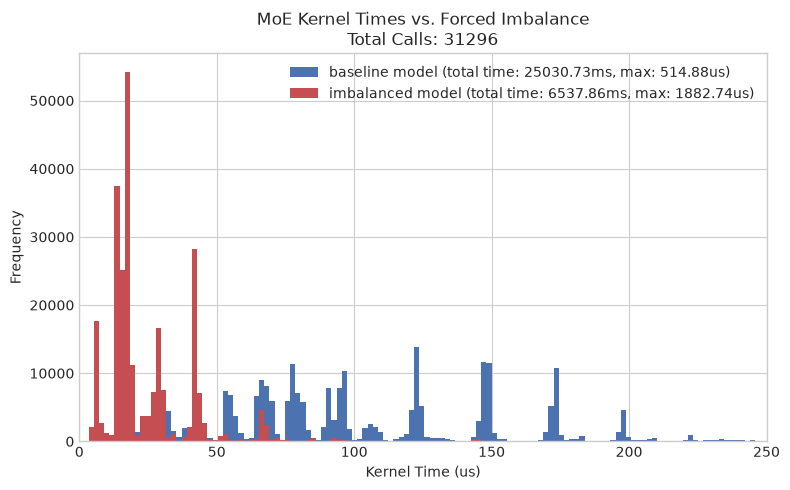

In [46]:
plot_kernel_hist(trace_results_balanced, trace_results_imbalanced)

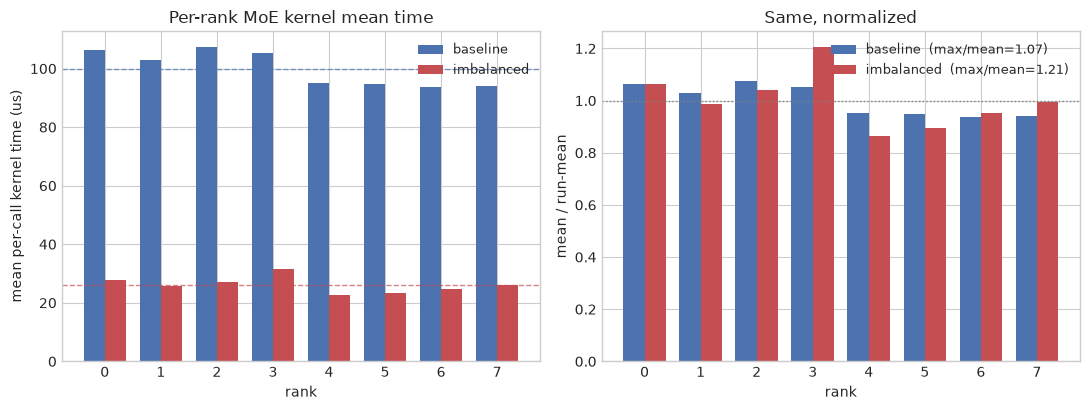

In [15]:
plot_moe(trace_results_balanced, trace_results_imbalanced)

In [11]:
trace_results_balanced

{'trace_dir': './vllm_benchmarking/traces/qwen_gpu8_batch16_samples100_imbalance0',
 'ranks': [0, 1, 2, 3, 4, 5, 6, 7],
 'per_rank_mean_us': [106.29635570040901,
  102.97083854166667,
  107.35326188650306,
  105.3665328156953,
  95.18188442612474,
  94.79830761119632,
  93.65503083461145,
  94.18368302658487],
 'per_rank_durs': [[149.922,
   173.41,
   172.481,
   197.09,
   173.25,
   173.442,
   96.416,
   177.986,
   172.642,
   197.666,
   70.977,
   129.57,
   173.633,
   173.026,
   148.321,
   173.635,
   123.617,
   123.65,
   148.386,
   148.002,
   197.922,
   70.688,
   71.649,
   174.082,
   232.834,
   198.531,
   179.458,
   202.69,
   122.85,
   149.122,
   96.481,
   123.841,
   148.769,
   172.93,
   147.778,
   96.609,
   172.93,
   122.273,
   97.441,
   173.826,
   123.105,
   198.338,
   122.753,
   147.873,
   147.778,
   96.865,
   148.705,
   197.026,
   208.45,
   148.482,
   178.69,
   122.817,
   123.777,
   177.282,
   147.042,
   172.898,
   150.85,
   123.